In [26]:
import seaborn as sns
import pandas as pd
import json
from pathlib import Path
from matplotlib.patches import Ellipse
import numpy as np

In [27]:
result_path = Path("../results/downstream_task")
bias_type = "less_positive_class"
less_bias_strength = "0.1"
method = "fw-mrs-temperature-svm"
data_set_name = "breast_cancer"
data_set_replacer = {"folktables_employment": "Employment", "folktables_income": "Income",
                        "breast_cancer": "Breast Cancer", "hr_analytics": "HR Analytic", "loan_prediction": "Loan"}

In [30]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

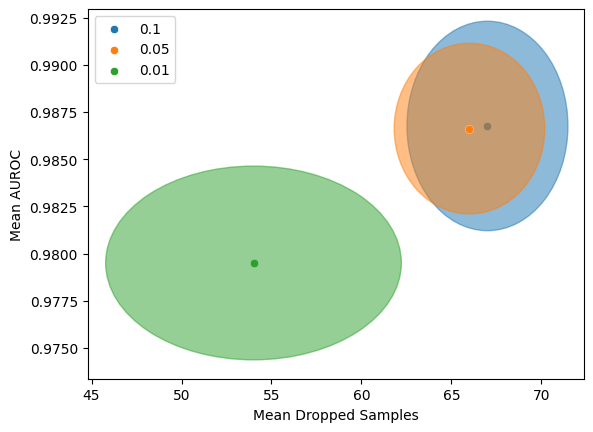

In [31]:
min_x = np.inf
min_y = np.inf
for key, dropped_value in dropped_samples.items():
    auroc_value = aurocs[key]
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1)
    colors = ax.collections[-1].get_facecolors()  # Get face colors of all points
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.5,
                       color=colors[0])
    ax.add_patch(ellipse)
    min_value = np.min(dropped_value.mean() - dropped_value.std())
    min_x =  min_value if min_value < min_x else min_x

    min_value = np.min(auroc_value.mean() - auroc_value.std())
    min_y =  min_value if min_value < min_y else min_y

_ = ax.set(xlim=min_x - 1, ylim=min_y - 0.001)
_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")